### SVM for Drought Prediction in Pueblo County, Colorado

In [13]:
# Importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score
import pyarrow

In [3]:
# Reading the dataset
df = pd.read_parquet('final_dataset_pueblo.parquet')

# Replacing NaN values with 0
df = df.fillna(0)
df.head()

,date,precip,max_temp,min_temp,gwl,daily_discharge_cfs,sm_pca,st_pca,target
0,2010-02-14,0.0,36,13,20.52,136.0,3.619512,0.190574,0
1,2010-02-15,0.0,41,7,20.51,129.0,3.470118,0.209177,0
2,2010-02-16,0.0,43,8,20.51,130.0,3.433721,0.197542,0
3,2010-02-17,0.0,51,10,20.51,132.0,3.351107,0.135033,0
4,2010-02-18,0.0,51,16,20.50,135.0,3.238121,0.107690,0


It'll be important to figure out exactly what years the droughts occur

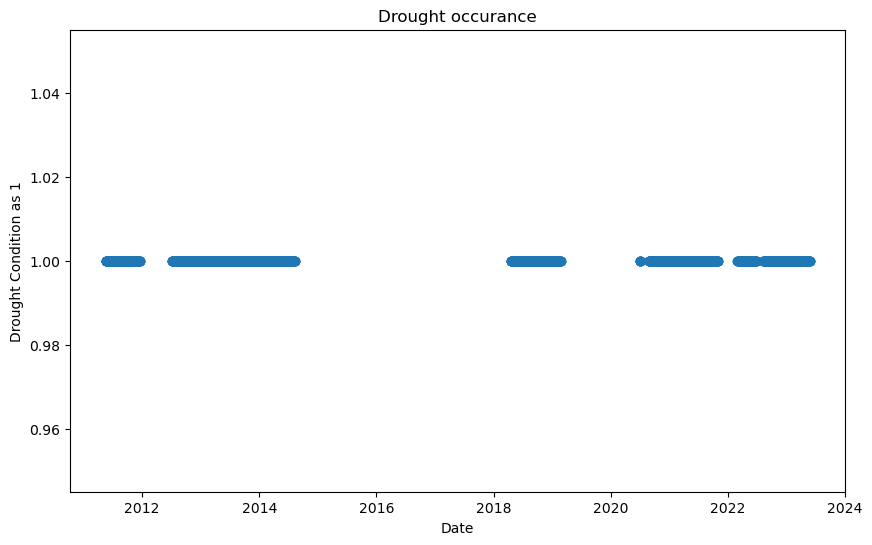

In [4]:
# Visualizing where target variable is 1 i.e there is drought

plt.figure(figsize=(10, 6))
plt.scatter(df[df['target'] == 1]['date'], df[df['target'] == 1]['target'])
plt.title('Drought occurance')
plt.xlabel('Date')
plt.ylabel('Drought Condition as 1')
plt.show()

Now I am going to list all the features, including the 2 obtained from PCA sm_pca and st_pca

In [5]:
# Following are the features list

features = ['precip', 'max_temp', 'min_temp', 'gwl', 'daily_discharge_cfs','sm_pca', 'st_pca']

# Target is target :p
target = 'target'

&emsp; ***What is multicollinearity?***


**Multicollinearity** occurs when two or more features (independent variables) in a regression model are highly correlated with each other. This means that these features provide redundant information about the variance in the dependent variable. When multicollinearity is present, it can make it difficult to assess the individual effect of each feature on the dependent variable because their effects are intertwined. It can be detected using various methods, including: *Correlation Matrix*: Examining the pairwise correlation coefficients between features.

In [6]:
# Checking for multicollinearity between features

corr = df[features].corr()
corr.style.background_gradient(cmap='coolwarm')

,precip,max_temp,min_temp,gwl,daily_discharge_cfs,sm_pca,st_pca
precip,1.000000,-0.032593,0.104749,-0.024576,0.206089,-0.024596,-0.001298
max_temp,-0.032593,1.000000,0.861268,0.063881,0.010227,-0.390845,-0.302978
min_temp,0.104749,0.861268,1.000000,0.046226,0.101598,-0.406750,-0.333921
gwl,-0.024576,0.063881,0.046226,1.000000,-0.056801,0.019720,-0.452011
daily_discharge_cfs,0.206089,0.010227,0.101598,-0.056801,1.000000,0.024787,0.018521
sm_pca,-0.024596,-0.390845,-0.406750,0.019720,0.024787,1.000000,0.312463
st_pca,-0.001298,-0.302978,-0.333921,-0.452011,0.018521,0.312463,1.000000


We can see that there is ***correlation*** between max_temp and min_temp, but as per the domain knowledge, I know that these two features are important and should be kept.

In [7]:
# Displaying the data before splitting

# display features 
display(df[features].head())
display(df[features].shape)

# display target
display(df[[target]].head())
display(df[target].shape)

,precip,max_temp,min_temp,gwl,daily_discharge_cfs,sm_pca,st_pca
0,0.0,36,13,20.52,136.0,3.619512,0.190574
1,0.0,41,7,20.51,129.0,3.470118,0.209177
2,0.0,43,8,20.51,130.0,3.433721,0.197542
3,0.0,51,10,20.51,132.0,3.351107,0.135033
4,0.0,51,16,20.50,135.0,3.238121,0.107690


(4881, 7)

,target
0,0
1,0
2,0
3,0
4,0


(4881,)

&emsp; ***Why is it important to split data?***

Splitting data into ***training*** and ***testing*** sets is a fundamental practice in machine learning to ensure that the model you build generalizes well to new, unseen data. The slit is important based upon:

1) **Assess Model Performance**: The training set is used to **fit the model**, while the testing set is used to **evaluate its performance**. The separation allows you to gauge how well the model will perform on new, unseen data, which is pretty important for understanding its predictive power.

2) **Avoid Overfitting**: Overfitting occurs when a model performs exceptionally well on the training data but poorly on unseen data because it has essentially memorized the training examples rather than learning the underlying patterns. By evaluating the model on a separate testing set, you can detect overfitting and make adjustments.

3) **Estimate Generalization Error**: The testing set provides an estimate of the model’s generalization error, which is the error rate on data it has not been trained on, i.e., it estimates helps in comparing different models or tuning hyperparameters to find the best-performing model.

4) **Validate Model Assumptions**: The testing set can help you validate the assumptions about the model. For instance, if a model performs poorly on the test set, it may indicate issues such as incorrect feature selection or a need for more data.

5) **Benchmarking**: Splitting the data allows you to benchmark your model’s performance against other models or baseline methodss which is essential for understanding the relative effectiveness of different approaches.

6) **Hyperparameter Tuning**: When tuning hyperparameters, it’s important to use a separate validation set (often derived from the training set) to evaluate different parameter settings before testing the final model on the untouched test set. This helps ensure that the final model is optimized and less likely to overfit.

Testing, depending on the size of the dataframe is usually done as a **70/30** split for smaller datasets, since this is note the case, I will split it **80/20**. There is no univerisal rule to this and I think it is "research specific" for each industry.

In [8]:
# Splitting up into training and testing tests for the feature sets and target sets

X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size = 0.2, random_state = 0)

# No. of instance with 1 in target variable for training set
display(y_train.value_counts())

# No. of instance with 1 in target variable for test set
display(y_test.value_counts())

target
0    2218
1    1686
Name: count, dtype: int64

target
0    536
1    441
Name: count, dtype: int64

In [9]:
# Scaling the features
# Feature scaling is performed to ensure that the model is not biased towards the features with higher magnitude

sc = StandardScaler()
X_train = sc.fit_transform(X_train)

&emsp; ***Implementing different types of kernels***

In [14]:
# Model building
classifier_linear = SVC(kernel='linear')
classifier_poly = SVC(kernel='poly')
classifier_rbf = SVC(kernel='rbf')

# Fitting the model
classifier_linear.fit(X_train, y_train)
classifier_poly.fit(X_train, y_train)
classifier_rbf.fit(X_train, y_train)

# Predicting the Test set results
pred_linear = classifier_linear.predict(sc.transform(X_test))
pred_poly = classifier_poly.predict(sc.transform(X_test))
pred_rbf = classifier_rbf.predict(sc.transform(X_test))

&emsp; ***Confussion Matrix***

A **confusion matrix** is a valuable tool for evaluating the performance of a decision tree classifier, or any classification model. It provides a detailed breakdown of how well the model is performing across different classes. It contains the True Positives (the number of spam emails correctly identified as spam), True Negatives (the number of non-spam emails correctly identified as non-spam), False Positives (the number of non-spam emails incorrectly identified as spam) and False Negatives (the number of spam emails incorrectly identified as non-spam)

&emsp; ***Important Metrics***

***Accuracy*** — **(TP + TN) / (TP + TN + FP + FN)** — The proportion of correctly classified instances out of the total instances.

***Precision*** — **TP / (TP + FP)** — The proportion of true positives among the instances classified as positive. It indicates how many of the positive classifications were actually correct.

***Recall (Sensitivity or True Positive Rate)*** — **TP / (TP + FN)** — The proportion of actual positives that were correctly identified. It tells you how well the model identifies positive instances. 


***F1 Score*** — **2 * (Precision * Recall) / (Precision + Recall)** — The harmonic mean of precision and recall, providing a balance between them. It’s useful when you need to balance precision and recall.


***Specificity (True Negative Rate)***: **TN / (TN + FP)** — The proportion of actual negatives that were correctly identified. It measures how well the model identifies negative instances.

***False Positive Rate*** **FP / (FP + TN)** — The proportion of actual negatives that were incorrectly classified as positive.

***False Negative Rate*** **FN / (FN + TP)** — The proportion of actual positives that were incorrectly classified as negative.

All in all, the *confusion matrix* helps you understand where your decision tree classifier is making errors, whether it’s more prone to false positives or false negatives, and provides a comprehensive view of the model’s performance across different classes. This information can guide you in tuning the model or choosing appropriate metrics based on the specific application needs.

Text(0.5, 1.0, 'Confusion Matrix for Simple SVM with RBF Kernel')

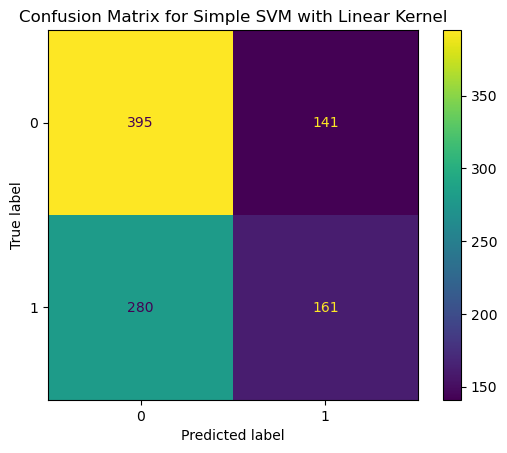

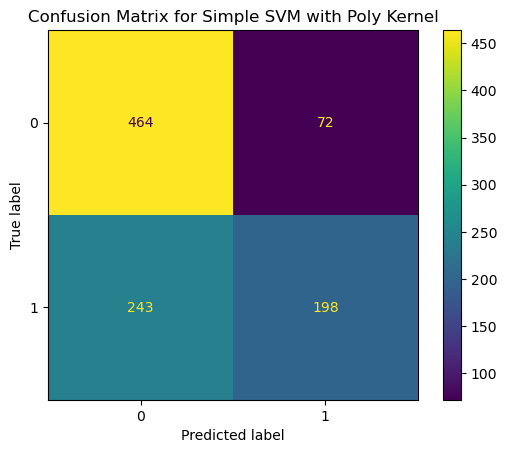

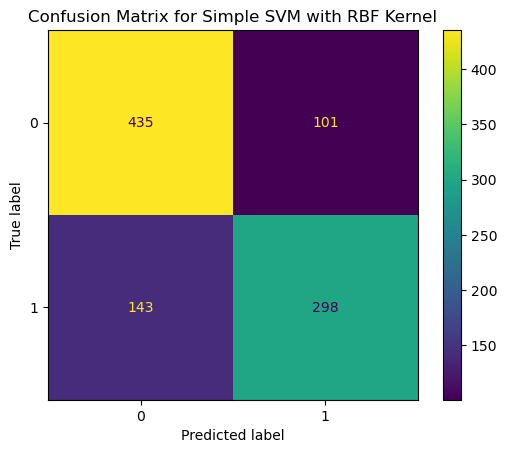

In [15]:
# Generating the confusion matrix for the linear kernel
cm_linear = confusion_matrix(y_test, pred_linear)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=classifier_linear.classes_)
disp.plot()
disp.ax_.set_title('Confusion Matrix for Simple SVM with Linear Kernel')

# Generating the confusion matrix for the poly kernel
cm_poly = confusion_matrix(y_test, pred_poly)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_poly, display_labels=classifier_poly.classes_)
disp.plot()
disp.ax_.set_title('Confusion Matrix for Simple SVM with Poly Kernel')

# Generating the confusion matrix for the RBF kernel
cm_rbf = confusion_matrix(y_test, pred_rbf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=classifier_rbf.classes_)
disp.plot()
disp.ax_.set_title('Confusion Matrix for Simple SVM with RBF Kernel')

In [16]:
# Calculating the accuracy, f1 score and recall for all the kernels
accuracy_linear = accuracy_score(y_test, pred_linear)
f1_linear = f1_score(y_test, pred_linear)
recall_linear = recall_score(y_test, pred_linear)
                             
accuracy_poly = accuracy_score(y_test, pred_poly)
f1_poly = f1_score(y_test, pred_poly)
recall_poly = recall_score(y_test, pred_poly)
                             
accuracy_rbf = accuracy_score(y_test, pred_rbf)
f1_rbf = f1_score(y_test, pred_rbf)
recall_rbf = recall_score(y_test, pred_rbf)

# Adding the scores to a dataframe
scores = pd.DataFrame({'Kernel': ['Linear', 'Poly', 'RBF']})
scores['Accuracy'] = [accuracy_linear, accuracy_poly, accuracy_rbf]
scores['F1 Score'] = [f1_linear, f1_poly, f1_rbf]
scores['Recall'] = [recall_linear, recall_poly, recall_rbf]

# Displaying the scores
display(scores)

,Kernel,Accuracy,F1 Score,Recall
0,Linear,0.569089,0.433378,0.365079
1,Poly,0.677584,0.556962,0.448980
2,RBF,0.750256,0.709524,0.675737


&emsp; ***Performance of the model***


The model seems to not be capturing the data distribution correctly, so I'll optimize the model using GridSearchCV for the 3 metrics.

In [17]:
# Implementing SVM with GridSearchCV for hyperparameter tuning of linear, rbf and poly kernels

params_grid = [{'C': [0.1, 0.5, 1, 5, 10], 'kernel': ['linear']},
               {'C': [0.1, 0.5, 1, 5, 10], 'kernel': ['rbf']},
               {'C': [0.1, 0.5, 1, 5, 10], 'kernel': ['poly'], 'degree': [2, 3, 4]}]

# Accuracy metric
classifier = SVC()
grid_search = GridSearchCV(estimator = classifier,
                           param_grid = params_grid,
                           scoring = 'accuracy',
                           cv = 10,
                           n_jobs = -1)

grid_search.fit(X_train, y_train)

# Displaying the best parameters
best_accuracy = grid_search.best_score_
best_parameters = grid_search.best_params_
print('Best Accuracy:', best_accuracy)
print('Best Parameters:', best_parameters)

# Recall metric
classifier = SVC()
grid_search = GridSearchCV(estimator = classifier,
                           param_grid = params_grid,
                           scoring = 'recall',
                           cv = 10,
                           n_jobs = -1)

grid_search.fit(X_train, y_train)

# Displaying the best parameters
best_recall = grid_search.best_score_
best_parameters = grid_search.best_params_
print('Best Recall:', best_recall)
print('Best Parameters:', best_parameters)

# F1 Score
classifier = SVC()
grid_search = GridSearchCV(estimator = classifier,
                           param_grid = params_grid,
                           scoring = 'f1',
                           cv = 10,
                           n_jobs = -1)

grid_search.fit(X_train, y_train)

# Displaying the best parameters
best_f1 = grid_search.best_score_
best_parameters = grid_search.best_params_
print('Best F1 Score:', best_f1)
print('Best Parameters:', best_parameters)

Best Accuracy: 0.8301678798609744
Best Parameters: {'C': 10, 'kernel': 'rbf'}
Best Recall: 0.798901098901099
Best Parameters: {'C': 10, 'kernel': 'rbf'}
Best F1 Score: 0.8023516662712753
Best Parameters: {'C': 10, 'kernel': 'rbf'}


After having found the best parameters, I'll fit the best SVM model to the training set (kernel = 'rbf', C = 10)

Accuracy: 0.8300921187308086
F1 Score: 0.8134831460674158
Recall Score: 0.8208616780045351


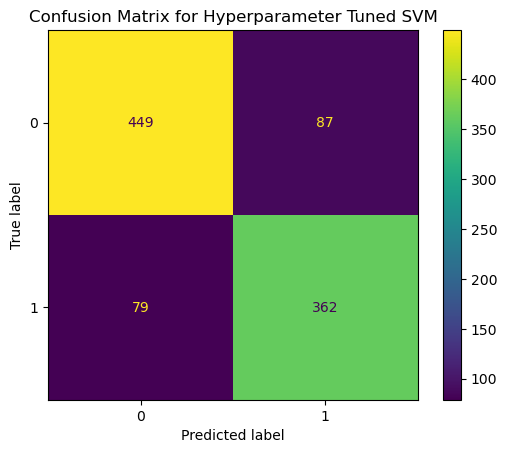

In [18]:
# Model building
classifier = SVC(kernel='rbf', C = 10)
classifier.fit(X_train, y_train)

# Predicting the Test set results
preds = classifier.predict(sc.transform(X_test))

# Generating the confusion matrix for the RBF kernel
cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
disp.ax_.set_title('Confusion Matrix for Hyperparameter Tuned SVM')

# Calculating the accuracy, f1 score and recall for the linear kernel 

accuracy = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds)
recall = recall_score(y_test, preds)

print(f'Accuracy: {accuracy}')
print(f'F1 Score: {f1}')
print(f'Recall Score: {recall}')